# Varying δ experiments for Private SpiderBoost

Sweep over the privacy parameter δ = 1/n^α for α ∈ {1.1, 1.4, 1.7, 2.0} at fixed ε = 1.0.
Results are compared against a non-private SPIDER baseline (SGD with variance-reduced gradient estimates, same architecture, matched gradient budget).

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lib' / 'model.py').is_file())
if str(ROOT / 'lib') not in sys.path:
    sys.path.insert(0, str(ROOT / 'lib'))

import jax
import jax.numpy as jnp
import numpy as np
from sklearn.metrics import roc_auc_score

import dimma
from dimma import TrainConfig, compute_noise_scales
from dimma.datasets import load_criteo

import model
import visualization as viz

## 2. Data and sweep configuration

In [2]:
FIGS_DIR = ROOT / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

data = load_criteo(features='integer', test_fraction=0.2, seed=0, device='cpu')
x_train, y_train = data.x_train, data.y_train
x_test, y_test = data.x_test, data.y_test
n_train, d = x_train.shape

# Sweep configuration — extend SEEDS to average over multiple runs.
EXPONENTS = [1.1, 1.4, 1.7, 2.0]   # δ = 1 / n_train ** α
SEEDS = [0]
EPSILON = 1.0
HIDDEN_DIMS = (64, 32)

BASE = dict(
    epsilon=EPSILON,
    L0=3.0,
    L1=5.0,
    T=200,
    q=30,
    b1=8192,
    b2=512,
    eta=0.01,
)

print(f'n_train={n_train}, d={d}')
print(f'Delta values: {[f"1/n^{a} = {1/n_train**a:.2e}" for a in EXPONENTS]}')

n_train=800000, d=13
Delta values: ['1/n^1.1 = 3.21e-07', '1/n^1.4 = 5.44e-09', '1/n^1.7 = 9.22e-11', '1/n^2.0 = 1.56e-12']


## 3. AUC helper

In [3]:
@jax.jit
def predict_logits(params, x):
    return model.forward(params, x)

def evaluate_auc(params, x, y):
    logits = predict_logits(params, x)
    return float(roc_auc_score(np.asarray(y), np.asarray(logits)))

## 4. Non-private baseline — eta sweep

The non-private baseline uses `model.train_spider` — the same anchor/variation step
structure as Private SpiderBoost (`T` total steps, phase length `q`, anchor batch size `b1`,
variation batch size `b2`), but without per-sample gradient clipping or Gaussian noise.
This isolates the cost of the privacy mechanism from differences in optimizer design.

**Why sweep eta (η) rather than fix it to the DP value.**
In the DP run, η is calibrated for heavily noised gradients: noise scales
σ₁ (anchor-step Gaussian noise) and σ₂ (variation-step Gaussian noise) are large
relative to the signal, forcing a conservative learning rate. Without noise,
a different — typically larger — η is optimal. Forcing the non-private baseline to
use the DP η would unfairly penalize it. T, q, b1, b2 are fixed to match the DP run
so that the gradient budget is identical; see ADR-0001.

**Selection criterion.**
The best η is selected by test ROC-AUC on `params_random` (the random iterate —
a uniformly sampled step from the training trajectory). This mirrors the output rule
of Private SpiderBoost, which also returns `params_random`, so the comparison is
on equal footing.


In [4]:
# Eta sweep for the non-private SPIDER baseline.
# T, q, b1, b2 are fixed to match the DP run (from BASE).
# Only η (the learning rate) is tuned here.
ETA_SWEEP = [0.001, 0.01, 0.1]

eta_sweep_results = {}  # eta -> list of params_random AUC values (one per seed)

for eta_candidate in ETA_SWEEP:
    aucs_random = []
    for seed in SEEDS:
        key = jax.random.PRNGKey(seed)
        init_p = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
        res = model.train_spider(
            x_train, y_train,
            init_params=init_p,
            T=BASE['T'],
            q=BASE['q'],
            b1=BASE['b1'],
            b2=BASE['b2'],
            eta=eta_candidate,
            seed=seed,
        )
        auc_rand = evaluate_auc(res.params_random, x_test, y_test)
        aucs_random.append(auc_rand)
        print(f'  eta={eta_candidate}  seed={seed}  AUC(params_random)={auc_rand:.4f}  ({sum(res.history.wall_time_s):.1f}s)')
    eta_sweep_results[eta_candidate] = aucs_random

# Select best eta by mean params_random AUC across seeds.
eta_mean_auc = {eta: float(np.mean(aucs)) for eta, aucs in eta_sweep_results.items()}
best_eta = max(eta_mean_auc, key=eta_mean_auc.get)
print(f'\nEta sweep results (mean params_random AUC over {len(SEEDS)} seed(s)):')
for eta_val, auc_val in eta_mean_auc.items():
    marker = ' <-- selected' if eta_val == best_eta else ''
    print(f'  eta={eta_val}  mean_AUC={auc_val:.4f}{marker}')


  eta=0.001  seed=0  AUC(params_random)=0.4900  (51.7s)


  eta=0.01  seed=0  AUC(params_random)=0.5732  (50.3s)


  eta=0.1  seed=0  AUC(params_random)=0.6813  (49.7s)

Eta sweep results (mean params_random AUC over 1 seed(s)):
  eta=0.001  mean_AUC=0.4900
  eta=0.01  mean_AUC=0.5732
  eta=0.1  mean_AUC=0.6813 <-- selected


In [5]:
# Run best-eta baseline over all seeds to get the final auc_baseline.
# auc_baseline is the mean params_random AUC under the best η.
# Note: best_eta differs from BASE['eta'] (the DP learning rate), which was tuned
# for noisy gradients (large σ₁, σ₂) and would underperform here.
auc_baseline_per_seed = []
for seed in SEEDS:
    key = jax.random.PRNGKey(seed)
    init_p = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
    res_best = model.train_spider(
        x_train, y_train,
        init_params=init_p,
        T=BASE['T'],
        q=BASE['q'],
        b1=BASE['b1'],
        b2=BASE['b2'],
        eta=best_eta,
        seed=seed,
    )
    auc_rand = evaluate_auc(res_best.params_random, x_test, y_test)
    auc_baseline_per_seed.append(auc_rand)

auc_baseline = float(np.mean(auc_baseline_per_seed))
print(f'Selected eta: {best_eta}  (DP eta: {BASE["eta"]} — differs because DP gradients carry '
      f'large Gaussian noise, σ₁ and σ₂, which forces a conservative learning rate)')
print(f'Non-private baseline AUC (params_random, mean over {len(SEEDS)} seed(s)): {auc_baseline:.4f}')


Selected eta: 0.1  (DP eta: 0.01 — differs because DP gradients carry large Gaussian noise, σ₁ and σ₂, which forces a conservative learning rate)
Non-private baseline AUC (params_random, mean over 1 seed(s)): 0.6813


## 5. δ sweep

In [6]:
# results[α] = list of (auc_random, auc_final) tuples, one per seed.
results = {alpha: [] for alpha in EXPONENTS}

for alpha in EXPONENTS:
    delta = 1.0 / (n_train ** alpha)
    print(f'--- α={alpha}  δ={delta:.2e} ---')
    for seed in SEEDS:
        cfg = TrainConfig(delta=delta, seed=seed, **BASE)
        noise_scales = compute_noise_scales(
            L0=cfg.L0, L1=cfg.L1, epsilon=cfg.epsilon, delta=cfg.delta,
            T=cfg.T, q=cfg.q, n=n_train, b1=cfg.b1, b2=cfg.b2,
        )
        key = jax.random.PRNGKey(seed)
        init_params = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
        res = dimma.train(
            x_train, y_train,
            per_sample_loss_fn=model.per_sample_bce_loss,
            init_params=init_params,
            config=cfg,
            noise_scales=noise_scales,
            sampler='poisson',
        )
        a_rand = evaluate_auc(res.params_random, x_test, y_test)
        a_fin = evaluate_auc(res.params_final, x_test, y_test)
        results[alpha].append((a_rand, a_fin))
        print(f'  seed={seed}  AUC(w\u0305)={a_rand:.4f}  AUC(w_T)={a_fin:.4f}  ({sum(res.history.wall_time_s):.1f}s)')

# Average over seeds.
auc_random_list = [float(np.mean([r[0] for r in results[a]])) for a in EXPONENTS]
auc_final_list  = [float(np.mean([r[1] for r in results[a]])) for a in EXPONENTS]

print('\nSummary (mean over seeds):')
for alpha, a_rand, a_fin in zip(EXPONENTS, auc_random_list, auc_final_list):
    print(f'  α={alpha}  AUC(w\u0305)={a_rand:.4f}  AUC(w_T)={a_fin:.4f}')

--- α=1.1  δ=3.21e-07 ---


  seed=0  AUC(w̅)=0.5528  AUC(w_T)=0.6068  (2.9s)
--- α=1.4  δ=5.44e-09 ---


  seed=0  AUC(w̅)=0.5529  AUC(w_T)=0.6069  (2.6s)
--- α=1.7  δ=9.22e-11 ---


  seed=0  AUC(w̅)=0.5530  AUC(w_T)=0.6070  (2.6s)
--- α=2.0  δ=1.56e-12 ---


  seed=0  AUC(w̅)=0.5531  AUC(w_T)=0.6071  (2.6s)

Summary (mean over seeds):
  α=1.1  AUC(w̅)=0.5528  AUC(w_T)=0.6068
  α=1.4  AUC(w̅)=0.5529  AUC(w_T)=0.6069
  α=1.7  AUC(w̅)=0.5530  AUC(w_T)=0.6070
  α=2.0  AUC(w̅)=0.5531  AUC(w_T)=0.6071


## 6. Plot

{'exponents': [1.1, 1.4, 1.7, 2.0], 'auc_random': [0.5528155252631356, 0.5529167419998302, 0.5530085808850055, 0.553092962516446], 'auc_final': [0.6067587080760334, 0.6068744815539853, 0.6069787218959553, 0.6070761771469952], 'auc_baseline': 0.6813096374724132}


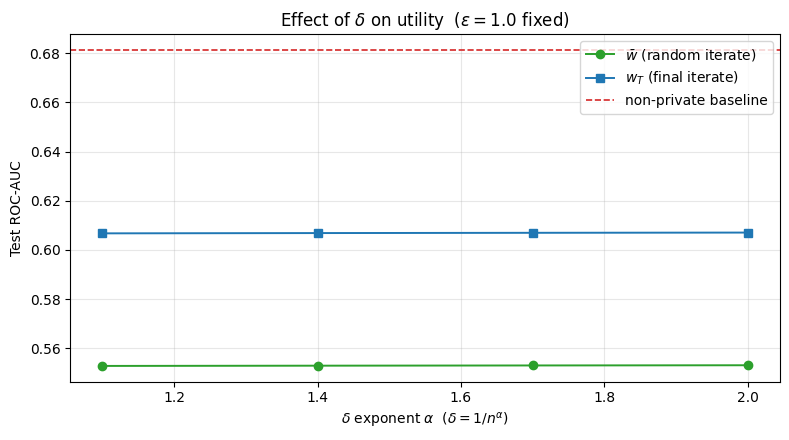

In [7]:
_ = viz.plot_delta_sweep(
    EXPONENTS, auc_random_list, auc_final_list, auc_baseline,
    FIGS_DIR / 'varying_delta_experiments.png',
)
print({
    'exponents': EXPONENTS,
    'auc_random': auc_random_list,
    'auc_final': auc_final_list,
    'auc_baseline': auc_baseline,
})